# Sales Prediction Using Python
### OASIS INFOBYTE — Data Science Internship — Task 5

**Objective:** Build a regression model that predicts product sales based on advertising
spend across different media channels (TV, Radio, Newspaper).

**Dataset:** Classic `Advertising.csv` dataset (200 rows) — TV, Radio, Newspaper spend (in
thousands of dollars) vs. Sales (in thousands of units). This is a well-known public dataset
used widely for teaching linear regression, originally from *An Introduction to Statistical
Learning* (James, Witten, Hastie, Tibshirani).

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 1. Load Dataset and Perform EDA

In [2]:
df = pd.read_csv("Advertising.csv")

# Drop an unnamed index column if the CSV includes one
if df.columns[0].lower().startswith("unnamed"):
    df = df.drop(columns=[df.columns[0]])

print("Shape:", df.shape)
df.head()


Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
# Null check
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [4]:
# Descriptive statistics
df.describe()


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


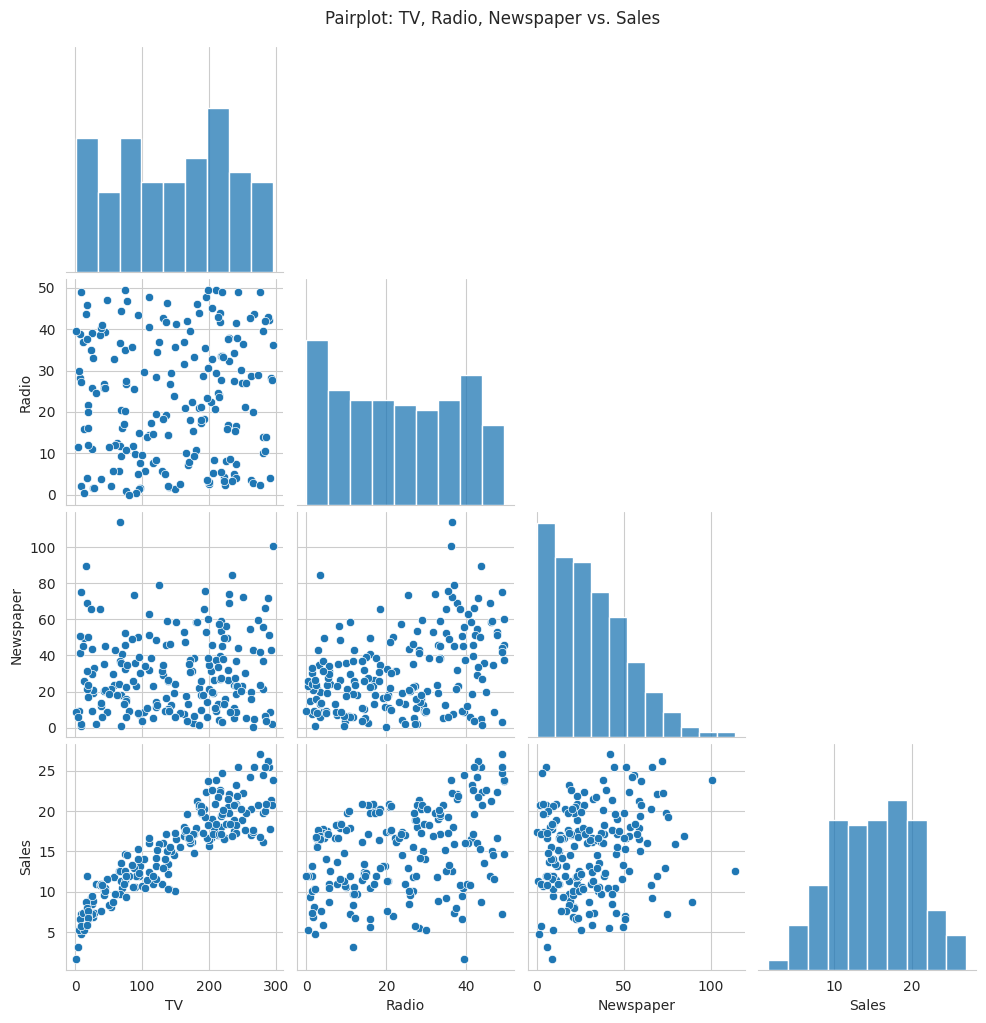

In [5]:
# Pairplot of all features
sns.pairplot(df, corner=True)
plt.suptitle("Pairplot: TV, Radio, Newspaper vs. Sales", y=1.02)
plt.show()


**Observation:** Sales appears to have a strong positive linear relationship with TV
spend, a moderate positive relationship with Radio spend, and a weak relationship with
Newspaper spend. This is explored further below.

## 2. Individual Scatter Plots: Sales vs. Each Channel

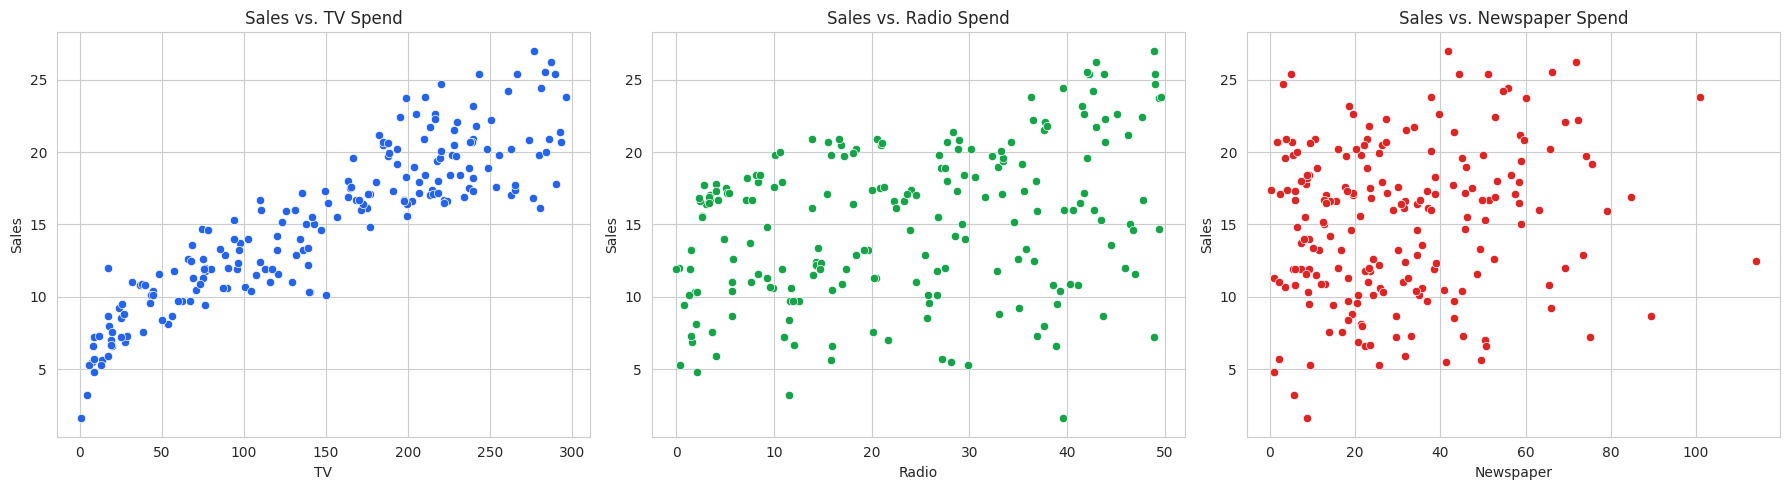

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="TV", y="Sales", ax=axes[0], color="#2563eb")
axes[0].set_title("Sales vs. TV Spend")

sns.scatterplot(data=df, x="Radio", y="Sales", ax=axes[1], color="#16a34a")
axes[1].set_title("Sales vs. Radio Spend")

sns.scatterplot(data=df, x="Newspaper", y="Sales", ax=axes[2], color="#dc2626")
axes[2].set_title("Sales vs. Newspaper Spend")

plt.tight_layout()
plt.show()


**Observation:** TV spend shows the clearest, tightest linear trend with Sales.
Radio shows a positive but noisier trend. Newspaper spend shows almost no discernible
linear trend — points are scattered with no clear slope.

## 3. Correlation Matrix Heatmap

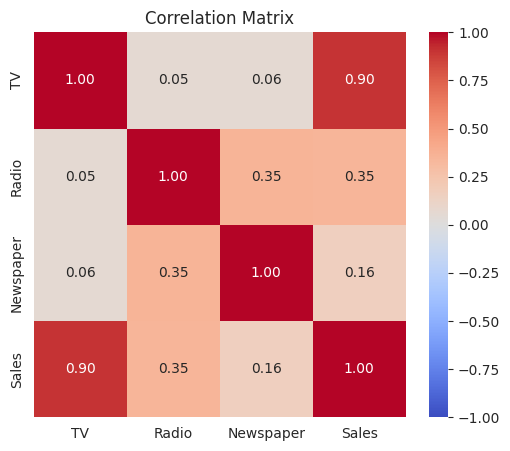

Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64

In [7]:
corr = df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

corr["Sales"].sort_values(ascending=False)


**Observation:** TV has the highest correlation with Sales (≈0.78), Radio is
moderate (≈0.58), and Newspaper is weak (≈0.23). TV and Radio are only weakly correlated
with each other, so multicollinearity is not a major concern here.

## 4. Train/Test Split

In [8]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 160  Test size: 40


## 5. Baseline Model — Linear Regression

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Linear Regression -> MAE: {mae_lin:.3f} | RMSE: {rmse_lin:.3f} | R2: {r2_lin:.3f}")


Linear Regression -> MAE: 1.275 | RMSE: 1.705 | R2: 0.906


## 6. Additional Model — Random Forest Regressor

In [10]:
rf_reg = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest -> MAE: {mae_rf:.3f} | RMSE: {rmse_rf:.3f} | R2: {r2_rf:.3f}")


Random Forest -> MAE: 0.903 | RMSE: 1.180 | R2: 0.955


## 7. Model Evaluation Summary

In [11]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [mae_lin, mae_rf],
    "RMSE": [rmse_lin, rmse_rf],
    "R2 Score": [r2_lin, r2_rf],
})
results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.274826,1.705215,0.905901
1,Random Forest Regressor,0.903092,1.180065,0.954935


## 8. Residual Plot (Best Model)

We identify the best model by the highest R² / lowest RMSE, then check whether its
residuals are randomly scattered (good) or show a systematic pattern (bad — signals a
missed nonlinearity).

Best-performing model: Random Forest Regressor


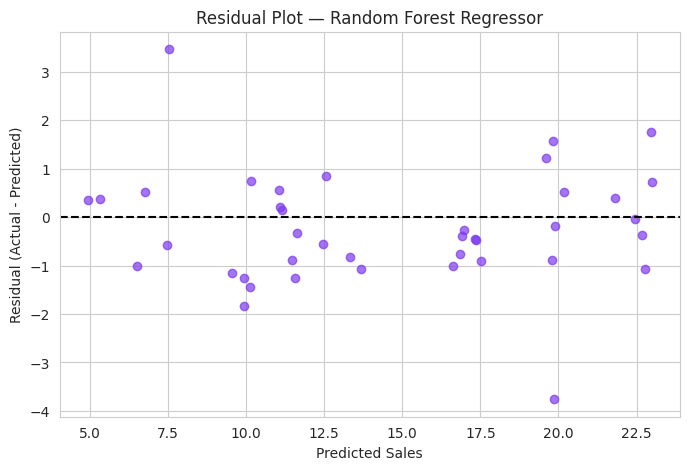

In [12]:
best_model_name = results.loc[results["R2 Score"].idxmax(), "Model"]
print("Best-performing model:", best_model_name)

y_pred_best = y_pred_rf if best_model_name == "Random Forest Regressor" else y_pred_lin
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, color="#7c3aed", alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()


**Observation:** The residuals scatter fairly randomly around zero with no obvious
funnel shape or curve, suggesting the model's errors are not systematically biased across
the range of predicted sales.

## 9. Interpretation — Which Channel Has the Highest Impact on Sales?

In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression Coefficient": lin_reg.coef_,
    "Random Forest Feature Importance": rf_reg.feature_importances_,
}).sort_values("Random Forest Feature Importance", ascending=False)

coef_df


,Feature,Linear Regression Coefficient,Random Forest Feature Importance
0,TV,0.054509,0.845301
1,Radio,0.100945,0.136298
2,Newspaper,0.004337,0.018400


/tmp/ipykernel_569/3213701691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Feature", y="Linear Regression Coefficient", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_569/3213701691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Feature", y="Random Forest Feature Importance", ax=axes[1], palette="Greens_d")


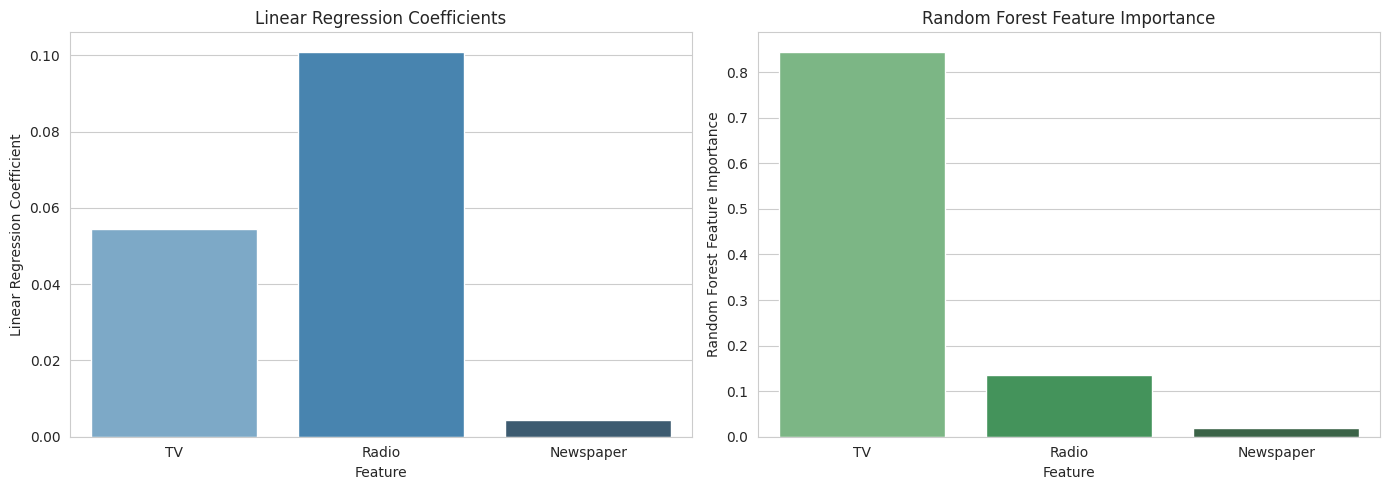

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=coef_df, x="Feature", y="Linear Regression Coefficient", ax=axes[0], palette="Blues_d")
axes[0].set_title("Linear Regression Coefficients")

sns.barplot(data=coef_df, x="Feature", y="Random Forest Feature Importance", ax=axes[1], palette="Greens_d")
axes[1].set_title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()


**Interpretation:** TV advertising spend has by far the largest impact on Sales,
both in terms of linear regression coefficient magnitude and Random Forest feature
importance. Radio has a smaller but still meaningful positive effect. Newspaper spend has
the smallest coefficient/importance and contributes the least to predicting Sales — this
matches the weak correlation and scattered relationship seen in the EDA above.

## 10. Conclusion

- Both models were evaluated using MAE, RMSE, and R².
- The **best-performing model** (see Section 7 summary table) achieved the lowest error
  and highest R² on the held-out test set.
- **TV** is the strongest driver of Sales, followed by **Radio**, with **Newspaper**
  contributing the least explanatory power.
- **Business takeaway:** Marketing budget allocated to TV and Radio advertising is
  associated with a substantially stronger lift in sales than the same budget spent on
  Newspaper advertising, based on this historical dataset.

*Note: This dataset reflects a specific (older) advertising mix and media landscape;
conclusions should be validated against current channel performance before being applied
directly to a live marketing budget.*
